In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.pipeline.features.min_features import (
    MIN_FEATURES,
    TARGET,
    build_min_dataset,
    validate_min_dataset,
)

warnings.filterwarnings("ignore")


In [ ]:
pd.set_option("display.max_columns", None)

# Pull silver.nba_player_gamelogs by season, engineer features, cache parquet.
from src.pipeline.gold import _read_silver_slice

CACHE_PATH = Path("data/cache/min_from_silver.parquet")
FORCE_REBUILD = False  # set True after changing min_features.py or silver data

# (season_year in silver, label used for holdout splits)
SEASONS = [
    ("2021-22", "S22"),
    ("2022-23", "S23"),
    ("2023-24", "S24"),
    ("2024-25", "S25"),
    ("2025-26", "S26"),
]
SEASON_TYPES = ("Regular Season", "Playoffs")


def load_season_from_silver(season_year: str) -> pd.DataFrame:
    parts = []
    for season_type in SEASON_TYPES:
        part = _read_silver_slice(season_year, season_type, league="nba")
        print(f"  {season_year} {season_type}: {len(part):,} rows")
        if not part.empty:
            parts.append(part)
    if not parts:
        return pd.DataFrame()
    return pd.concat(parts, ignore_index=True).sort_values("GAME_DATE")


if CACHE_PATH.exists() and not FORCE_REBUILD:
    df = pd.read_parquet(CACHE_PATH)
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    print(f"Loaded cache {CACHE_PATH}: {df.shape[0]:,} rows × {df.shape[1]} cols")
else:
    season_dfs = []
    season_map = {}
    for i, (season_year, label) in enumerate(SEASONS):
        part = load_season_from_silver(season_year)
        if part.empty:
            print(f"  ⚠ skip {season_year}: no silver rows")
            continue
        season_map[len(season_dfs)] = label
        season_dfs.append(part)
        print(f"  → {label}: {len(part):,} raw rows")

    if not season_dfs:
        raise RuntimeError("No silver seasons loaded — run fetch_raw.py first")

    print("Building MIN features (this can take a few minutes)...")
    df = build_min_dataset(season_dfs, season_map=season_map)
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values("GAME_DATE").reset_index(drop=True)

    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(CACHE_PATH, index=False)
    print(f"Wrote {CACHE_PATH}: {df.shape[0]:,} rows × {df.shape[1]} cols")

df.sample(5)


In [ ]:
# Validate engineered frame (no GAME_ID×PLAYER_ID dups, MIN_FEATURES present)
summary = validate_min_dataset(df)
print(f"Validated MIN frame: {summary['rows']:,} rows × {summary['cols']} cols")
print(f"Features OK ({summary['features']}): all {len(MIN_FEATURES)} MIN_FEATURES present")
print("Season counts:")
print(pd.Series(summary["seasons"]).sort_index())

# Training subset retained after SHAP + permutation consensus
# (dropped 9/23: MIN_P10_L10, ACTIVE_STARS_COUNT, PIE_lag1, MIN_P90_L10,
#  MIN_STD_L10, USG_PCT_lag1, AST_PCT_lag1, USG_PCT_lag2, TOP_PLAYER_ACTIVE)
FEATURE_COLS = [
    "CONSEC_STARTS",
    "MIN_10_ewm",
    "TEAM_MIN_RANK_L10",
    "STARTER_ROLL10_PCT",
    "MIN_SEASON_MEAN",
    "MIN_SUM_LAST_7_DAYS",
    "TEAM_USG_RANK_L10",
    "AST_PCT_lag2",
    "MIN_SEASON_STD",
    "GAMES_PLAYED_LAST_14_DAYS",
    "GAMES_PLAYED_LAST_7_DAYS",
    "MIN_RATE_OF_CHANGE",
    "PIE_lag2",
    "SPD_10_ewm",
]
# Alias so later SHAP/ablation/save cells use the training feature set
MIN_FEATURES = FEATURE_COLS

print(df.shape)
df.sample(3)


In [ ]:
# Feature list already validated via validate_min_dataset (MIN_FEATURES present)
print(f"Features ({len(FEATURE_COLS)})")
print(FEATURE_COLS)
df[FEATURE_COLS].dtypes


In [ ]:
# ── Train/holdout split ───────────────────────────────────────────────────────
# CHANGED: S26 is held out entirely. The model never sees it during training
# or hyperparameter evaluation. Evaluate on it ONCE at the very end.

HOLDOUT_SEASON = "S26"
ID_COLS = ["GAME_ID", "PLAYER_ID", "SEASON", "PLAYER_NAME", "GAME_DATE"]
TARGET_COL = TARGET  # "MIN"
ROLE_COL = "STARTING"

df_model = df[df["SEASON"] != HOLDOUT_SEASON].copy()   # S22–S25
df_holdout = df[df["SEASON"] == HOLDOUT_SEASON].copy()  # S26 blind test

KEEP_COLS = list(dict.fromkeys(
    FEATURE_COLS + ID_COLS + [TARGET_COL, ROLE_COL]
))

ppm_df = (
    df_model[KEEP_COLS]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

ppm_holdout = (
    df_holdout[KEEP_COLS]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

X = ppm_df[FEATURE_COLS].copy()
y = ppm_df[TARGET_COL]

print(f"Train pool (S22–S25) : {len(ppm_df):,} rows")
print(f"Holdout   (S26)      : {len(ppm_holdout):,} rows")
print(f"Date range (train)   : {ppm_df['GAME_DATE'].min().date()} → {ppm_df['GAME_DATE'].max().date()}")
print(f"Date range (holdout) : {ppm_holdout['GAME_DATE'].min().date()} → {ppm_holdout['GAME_DATE'].max().date()}")


In [8]:
# Build model matrices — ID/meta cols stay on ppm_df, not in X
X = ppm_df[FEATURE_COLS].copy()
y = ppm_df[TARGET_COL]

assert X.select_dtypes(exclude=["number", "bool", "category"]).empty, \
    "Non-numeric columns still present in X!"

print(f"X shape: {X.shape}  |  y shape: {y.shape}")
print(X.dtypes.value_counts())
X.sample(10)


X shape: (106429, 14)  |  y shape: (106429,)
float64    11
int64       3
Name: count, dtype: int64


,CONSEC_STARTS,MIN_10_ewm,TEAM_MIN_RANK_L10,STARTER_ROLL10_PCT,MIN_SEASON_MEAN,MIN_SUM_LAST_7_DAYS,TEAM_USG_RANK_L10,AST_PCT_lag2,MIN_SEASON_STD,GAMES_PLAYED_LAST_14_DAYS,GAMES_PLAYED_LAST_7_DAYS,MIN_RATE_OF_CHANGE,PIE_lag2,SPD_10_ewm
48250,53,28.93,3.0,1.0,27.831769,25.6,8.0,0.043,4.571916,4,1,-0.29,0.027,4.42
25607,45,17.27,14.0,1.0,21.384007,62.2,10.0,0.000,6.250061,10,4,-3.45,-0.100,4.38
66435,0,14.42,7.0,0.0,12.355952,61.0,8.0,0.200,6.143006,5,4,-0.15,0.146,4.40
12050,0,19.97,9.0,1.0,17.203939,0.0,7.0,0.118,7.506689,0,0,0.25,0.122,4.09
97312,0,21.49,7.0,0.4,15.194605,15.5,6.0,0.238,6.600244,3,1,3.57,0.142,4.20
23709,29,31.67,1.0,1.0,23.361075,121.9,7.0,0.136,9.706891,8,4,-0.59,0.083,4.42
62572,0,26.77,3.0,0.0,25.268276,79.3,3.0,0.056,6.142407,7,3,2.76,0.116,4.01
60356,0,19.79,8.0,0.1,19.573016,42.1,4.0,0.273,5.199719,4,2,2.06,0.089,4.42
17010,0,19.14,7.0,0.2,20.815504,50.0,9.0,0.273,8.126076,6,3,-3.55,0.080,4.08
65880,38,31.54,3.0,1.0,33.845360,118.5,4.0,0.125,5.245938,7,4,-1.69,0.072,4.24


In [9]:
from sklearn.model_selection import TimeSeriesSplit

quantiles = [0.10, 0.50, 0.90]

XGB_PARAMS = dict(
    objective             = "reg:quantileerror",
    n_estimators          = 1695,
    max_depth             = 3,
    learning_rate         = 0.052852647946832816,
    subsample             = 0.5916232263322159,
    colsample_bytree      = 0.6284413523882679,
    reg_alpha             = 0.022871045941195746,
    reg_lambda            = 2.0960269065270034,
    min_child_weight      = 8,
    n_jobs                = -1,
    random_state          = 42,
    early_stopping_rounds = 50,
)

def fit_quantile_models(X_train, y_train, X_val, y_val):
    """Train one XGB quantile model per quantile, return preds dict."""
    models = {}
    preds  = {}
    for q in quantiles:
        m = XGBRegressor(**XGB_PARAMS, quantile_alpha=q)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
        key         = f"q_{q:.2f}"
        models[key] = m
        preds[key]  = m.predict(X_val)
    return models, preds


In [10]:
# ── Helpers ───────────────────────────────────────────────────────────────────

MIN_TIERS = {
    "<10 min":  lambda a: a < 10,
    "10-20 min": lambda a: (a >= 10) & (a < 20),
    "20-30 min": lambda a: (a >= 20) & (a < 30),
    "30+ min":  lambda a: a >= 30,
}


def score_fold(actual, preds, models, fold_label, starting=None):
    """
    Score a single fold.
    CHANGED: now accepts `starting` (bool/int array) and reports
    stratified MAE + coverage across roles and minutes tiers.
    Coverage is tracked per-fold so we can report mean±std at the end.
    """
    lower  = preds["q_0.10"]
    median = preds["q_0.50"]
    upper  = preds["q_0.90"]

    mae      = mean_absolute_error(actual, median)
    r2       = r2_score(actual, median)
    coverage = np.mean((actual >= lower) & (actual <= upper))

    metrics = {
        "fold":           fold_label,
        "n":              len(actual),
        "mae":            mae,
        "r2":             r2,
        "coverage_80pct": coverage,
        "best_iters":     {k: models[k].best_iteration for k in models},
    }

    print(f"\n{fold_label}")
    print(f"  Overall  | n={len(actual):5d} | MAE: {mae:.3f} | R²: {r2:.3f} | 80% Coverage: {coverage:.1%}")

    # ── Role stratification (starter vs bench) ────────────────────────────────
    if starting is not None:
        for role, mask in [("Starters", starting == 1), ("Bench", starting == 0)]:
            if mask.sum() == 0:
                continue
            r_mae = mean_absolute_error(actual[mask], median[mask])
            r_cov = np.mean((actual[mask] >= lower[mask]) & (actual[mask] <= upper[mask]))
            metrics[f"mae_{role}"]      = r_mae
            metrics[f"coverage_{role}"] = r_cov
            print(f"  {role:10s} | n={mask.sum():5d} | MAE: {r_mae:.3f} | Coverage: {r_cov:.1%}")

    # ── Minutes-tier stratification ────────────────────────────────────────────
    for tier, fn in MIN_TIERS.items():
        mask = fn(actual)
        if mask.sum() == 0:
            continue
        t_mae = mean_absolute_error(actual[mask], median[mask])
        t_cov = np.mean((actual[mask] >= lower[mask]) & (actual[mask] <= upper[mask]))
        metrics[f"mae_{tier}"]      = t_mae
        metrics[f"coverage_{tier}"] = t_cov
        print(f"  {tier:10s} | n={mask.sum():5d} | MAE: {t_mae:.3f} | Coverage: {t_cov:.1%}")

    return metrics


# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — TimeSeriesSplit (feature selection / hyperparam comparison only)
# ════════════════════════════════════════════════════════════════════════════

print("── Phase 1: TimeSeriesSplit ─────────────────────────────────────────")
tscv         = TimeSeriesSplit(n_splits=5)
tscv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    starting_val = ppm_df["STARTING"].iloc[val_idx].values

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models,
                         f"TSCV fold {fold+1}", starting=starting_val)
    tscv_results.append(metrics)

maes = [r["mae"]          for r in tscv_results]
r2s  = [r["r2"]           for r in tscv_results]
covs = [r["coverage_80pct"] for r in tscv_results]
print(f"\nTimeSeriesSplit Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")


# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Walk-Forward (date-based, production simulation)
#
# CHANGED: splits are now on unique GAME_DATEs, not row indices.
# This ensures no single game date is split across train/val,
# which was the root cause of intra-game leakage in the original code.
# ════════════════════════════════════════════════════════════════════════════

print("\n── Phase 2: Walk-Forward Validation (date-based) ───────────────────")

assert ppm_df["GAME_DATE"].is_monotonic_increasing, "ppm_df must be sorted by GAME_DATE"

unique_dates  = ppm_df["GAME_DATE"].unique()          # sorted unique game dates
n_dates       = len(unique_dates)

TRAIN_WINDOW  = round(n_dates * 0.50)                 # dates in each training window
STEP_SIZE     = round(n_dates * 0.10)                 # dates to advance each fold
N_FOLDS       = 4

print(f"Unique game dates in pool : {n_dates}")
print(f"Training window           : {TRAIN_WINDOW} dates (~{TRAIN_WINDOW/n_dates:.0%})")
print(f"Step size                 : {STEP_SIZE} dates (~{STEP_SIZE/n_dates:.0%})")

wf_results  = []
models_last = None   # will hold the final fold's models for downstream cells

for fold in range(N_FOLDS):
    d_train_start = fold * STEP_SIZE
    d_train_end   = d_train_start + TRAIN_WINDOW
    d_val_end     = d_train_end   + STEP_SIZE

    if d_val_end > n_dates:
        print(f"\nFold {fold+1}: not enough dates remaining — stopping at {fold} folds.")
        break

    train_dates = unique_dates[d_train_start:d_train_end]
    val_dates   = unique_dates[d_train_end:d_val_end]

    # CHANGED: mask on dates so every player in a given game date
    # lands on the same side of the split — no intra-game leakage.
    train_mask = ppm_df["GAME_DATE"].isin(train_dates)
    val_mask   = ppm_df["GAME_DATE"].isin(val_dates)

    X_tr,  X_val  = X[train_mask],              X[val_mask]
    y_tr,  y_val  = y[train_mask],              y[val_mask]
    starting_val  = ppm_df["STARTING"][val_mask].values

    label = (f"WF fold {fold+1}  "
             f"({train_dates[-1].date()} → {val_dates[-1].date()})")

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models, label, starting=starting_val)
    metrics.update({
        "train_start": train_dates[0],
        "train_end":   train_dates[-1],
        "val_end":     val_dates[-1],
        # stash slices so downstream cells can reconstruct without retraining
        "train_mask":  train_mask,
        "val_mask":    val_mask,
    })
    wf_results.append(metrics)

    # keep last fold for residual plots + SHAP
    models_last = models
    preds_last  = preds
    X_val_last  = X_val
    y_val_last  = y_val
    starting_last = starting_val

# ── Walk-forward summary ──────────────────────────────────────────────────────
maes = [r["mae"]           for r in wf_results]
r2s  = [r["r2"]            for r in wf_results]
covs = [r["coverage_80pct"] for r in wf_results]

print(f"\n{'─'*60}")
print(f"Walk-Forward Summary ({len(wf_results)}/{N_FOLDS} folds)")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")

# CHANGED: per-fold coverage table across all folds — catches folds where
# the interval collapses or over-covers without hiding it in the mean.
print(f"\n{'─'*60}")
print("Per-fold coverage breakdown (target 80%):")
print(f"  {'Fold':<45} {'Coverage':>10}  {'Starters':>10}  {'Bench':>10}")
for r in wf_results:
    s_cov = r.get("coverage_Starters", float('nan'))
    b_cov = r.get("coverage_Bench",    float('nan'))
    print(f"  {r['fold']:<45} {r['coverage_80pct']:>9.1%}  {s_cov:>9.1%}  {b_cov:>9.1%}")

# CHANGED: stratified MAE summary across all folds
print(f"\nPer-fold MAE by minutes tier:")
tier_keys = list(MIN_TIERS.keys())
header = f"  {'Fold':<45} " + "  ".join(f"{t:>10}" for t in tier_keys)
print(header)
for r in wf_results:
    row = f"  {r['fold']:<45} "
    row += "  ".join(f"{r.get(f'mae_{t}', float('nan')):>10.3f}" for t in tier_keys)
    print(row)

# Drift check
max_mae = max(maes)
print(f"\nMAE over folds (stable = good, rising = model aging):")
for r in wf_results:
    bar = "█" * int((r["mae"] / max_mae) * 20)
    print(f"  {r['fold']:<45} {r['mae']:.3f}  {bar}")

last_fold = wf_results[-1]

── Phase 1: TimeSeriesSplit ─────────────────────────────────────────

TSCV fold 1
  Overall  | n=17738 | MAE: 4.562 | R²: 0.639 | 80% Coverage: 76.0%
  Starters   | n= 9178 | MAE: 4.523 | Coverage: 74.5%
  Bench      | n= 8560 | MAE: 4.602 | Coverage: 77.5%
  <10 min    | n= 1369 | MAE: 6.409 | Coverage: 50.9%
  10-20 min  | n= 4465 | MAE: 4.024 | Coverage: 86.7%
  20-30 min  | n= 5821 | MAE: 4.591 | Coverage: 80.1%
  30+ min    | n= 6083 | MAE: 4.512 | Coverage: 69.8%

TSCV fold 2
  Overall  | n=17738 | MAE: 4.318 | R²: 0.658 | 80% Coverage: 79.5%
  Starters   | n= 9227 | MAE: 4.153 | Coverage: 79.8%
  Bench      | n= 8511 | MAE: 4.498 | Coverage: 79.2%
  <10 min    | n= 1382 | MAE: 6.727 | Coverage: 48.8%
  10-20 min  | n= 4403 | MAE: 4.100 | Coverage: 86.1%
  20-30 min  | n= 5740 | MAE: 4.436 | Coverage: 83.0%
  30+ min    | n= 6213 | MAE: 3.828 | Coverage: 78.5%

TSCV fold 3
  Overall  | n=17738 | MAE: 4.273 | R²: 0.672 | 80% Coverage: 79.0%
  Starters   | n= 9097 | MAE: 4.192 | C

In [27]:
# import optuna
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_absolute_error
# from xgboost import XGBRegressor

# tscv = TimeSeriesSplit(n_splits=4)  # fewer splits = faster tuning

# def objective(trial):
#     params = {
#         "objective": "reg:quantileerror",
#         "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#         "n_jobs": -1,
#         "random_state": 42,
#         "early_stopping_rounds": 50,
#     }
#     maes = []
#     for train_idx, val_idx in tscv.split(X):
#         X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
#         m = XGBRegressor(**params, quantile_alpha=0.5)
#         m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
#         pred = m.predict(X_val)
#         maes.append(mean_absolute_error(y_val, pred))
#     return float(np.mean(maes))

# study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
# study.optimize(objective, n_trials=40, show_progress_bar=True)

# print("Best MAE (mean over TSCV, median model):", study.best_value)
# print("Best params:", study.best_params)

### Residual Visuals

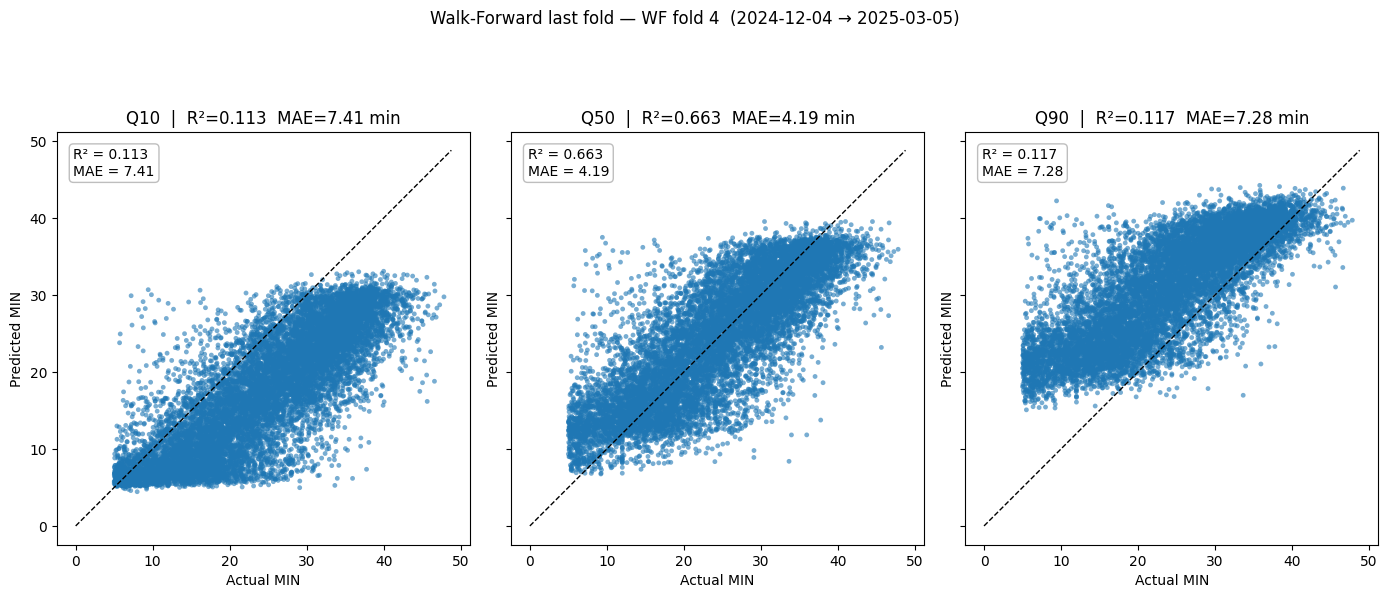

Per-quantile fit on last validation fold:
  Q10: R²=+0.113  MAE=7.410 min
  Q50: R²=+0.663  MAE=4.186 min
  Q90: R²=+0.117  MAE=7.276 min

Coverage per quantile (should match quantile value):
  Q10: 9.6%  (target 10%, delta -0.4%)  ✓
  Q50: 50.3%  (target 50%, delta +0.3%)  ✓
  Q90: 90.8%  (target 90%, delta +0.8%)  ✓

80% interval width (Q10→Q90):
  mean   : 13.67 min
  median : 13.53 min
  std    : 1.98 min


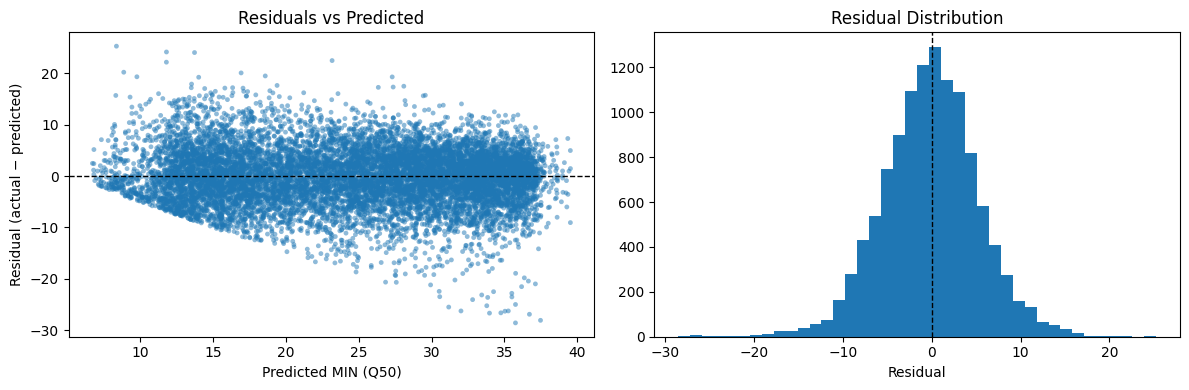


Residual summary:
  mean bias : -0.163 min  (close to 0 = unbiased)
  std       : 5.422 min

Residuals by role:
  Starters   | n= 6002 | bias=-0.537 | std=5.308
  Bench      | n= 5711 | bias=+0.231 | std=5.512

Residuals by minutes tier:
  <10 min    | n=  894 | bias=-6.310 | std=4.370
  10-20 min  | n= 3047 | bias=-2.227 | std=4.885
  20-30 min  | n= 3904 | bias=-0.072 | std=5.302
  30+ min    | n= 3868 | bias=+2.793 | std=4.075


In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# ── pull directly from stored walk-forward variables ─────────────────────────
# models_last, preds_last, X_val_last, y_val_last, starting_last
# are all set at the end of the walk-forward loop — no reconstruction needed.

y_true    = y_val_last.values
pred_low  = preds_last["q_0.10"]
pred_mid  = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]

preds_plot = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

# ── predicted vs actual scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
scatter_metrics = {}

for ax, (name, y_pred) in zip(axes, preds_plot.items()):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    scatter_metrics[name] = {"R2": r2, "MAE": mae}

    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name}  |  R²={r2:.3f}  MAE={mae:.2f} min")
    ax.set_xlabel("Actual MIN")
    ax.set_ylabel("Predicted MIN")
    ax.set_aspect("equal", adjustable="box")
    ax.text(
        0.04, 0.96,
        f"R² = {r2:.3f}\nMAE = {mae:.2f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )

plt.suptitle(f"Walk-Forward last fold — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

print("Per-quantile fit on last validation fold:")
for name, m in scatter_metrics.items():
    print(f"  {name}: R²={m['R2']:+.3f}  MAE={m['MAE']:.3f} min")

# ── coverage per quantile ─────────────────────────────────────────────────────
print("\nCoverage per quantile (should match quantile value):")
for name, y_pred in preds_plot.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta    = coverage - q_target
    flag     = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})  {flag}")

# ── interval width ────────────────────────────────────────────────────────────
interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean   : {interval_width.mean():.2f} min")
print(f"  median : {np.median(interval_width):.2f} min")
print(f"  std    : {interval_width.std():.2f} min")

# ── residual plot ─────────────────────────────────────────────────────────────
residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted MIN (Q50)")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.3f} min  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.3f} min")

# ── residuals stratified by role and minutes tier ─────────────────────────────
# uses starting_last set in the walk-forward loop
# ── re-derive starting using X_val_last.index (guaranteed same length as residuals) ──
starting_last = ppm_df.loc[X_val_last.index, "STARTING"].values

print("\nResiduals by role:")
for role, mask in [("Starters", starting_last == 1), ("Bench", starting_last == 0)]:
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {role:10s} | n={mask.sum():5d} | bias={r.mean():+.3f} | std={r.std():.3f}")

print("\nResiduals by minutes tier:")
for tier, fn in MIN_TIERS.items():
    mask = fn(y_true)
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {tier:10s} | n={mask.sum():5d} | bias={r.mean():+.3f} | std={r.std():.3f}")


── q_0.10 ──


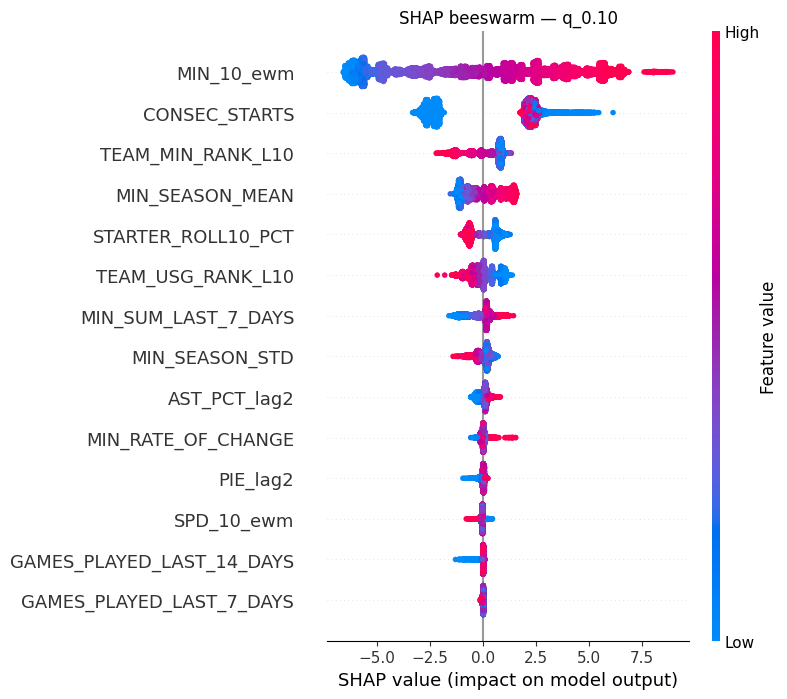


── q_0.50 ──


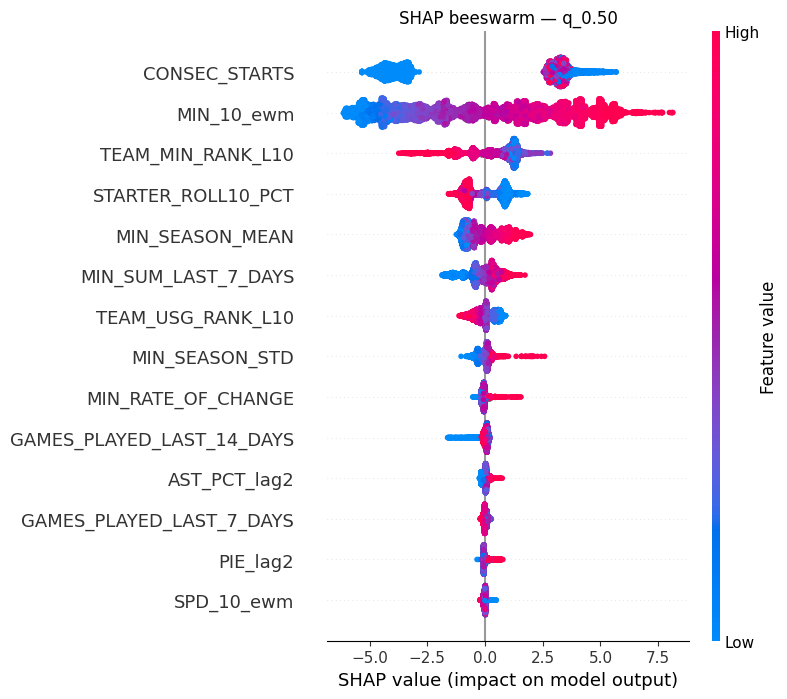


── q_0.90 ──


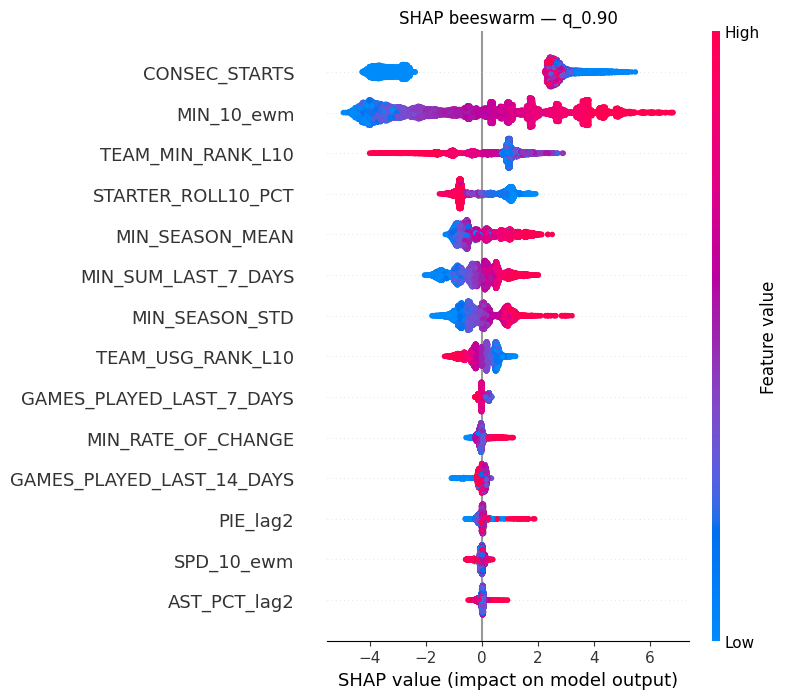

In [12]:
import shap

for q_key, model in models_last.items():
    explainer   = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_val_last)

    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP beeswarm — {q_key}")
    plt.tight_layout()
    plt.show()

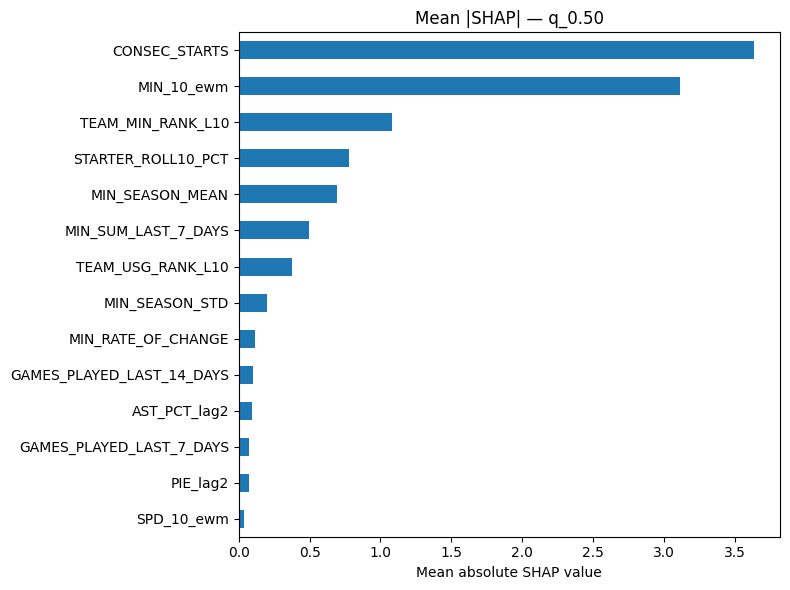

In [13]:
model = models_last["q_0.50"]

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=MIN_FEATURES).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()

In [14]:
# ── Permutation importance — on VALIDATION set ───────────────────────────────
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

def pinball_50(y_true, y_pred, alpha=0.50):
    residual = y_true - y_pred
    return -np.mean(np.where(residual >= 0, alpha * residual, (alpha - 1) * residual))

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature":    X_val_last.columns,
        "importance": result.importances_mean,   # ← no flip
        "std":        result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(5)
pi_df["std"]        = pi_df["std"].round(5)

pi_df["p_value"] = sp_stats.ttest_1samp(
    result.importances, 0.0, axis=1
).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())

Permutation importance (val set) — higher = more important, significant = p<0.05
                      feature  importance      std  p_value  significant
1                  MIN_10_ewm     0.98061  0.01443   0.0000         True
2               CONSEC_STARTS     0.73419  0.01274   0.0000         True
3           TEAM_MIN_RANK_L10     0.20445  0.00484   0.0000         True
4          STARTER_ROLL10_PCT     0.10392  0.00522   0.0000         True
5             MIN_SEASON_MEAN     0.06543  0.00354   0.0000         True
6         MIN_SUM_LAST_7_DAYS     0.04625  0.00316   0.0000         True
7           TEAM_USG_RANK_L10     0.02127  0.00185   0.0000         True
8              MIN_SEASON_STD     0.00730  0.00126   0.0000         True
9   GAMES_PLAYED_LAST_14_DAYS     0.00409  0.00089   0.0000         True
10         MIN_RATE_OF_CHANGE     0.00113  0.00082   0.0000         True
11               AST_PCT_lag2     0.00096  0.00046   0.0000         True
12   GAMES_PLAYED_LAST_7_DAYS     0.00095  

In [15]:
from sklearn.metrics import mean_squared_error

# ── pull train/val slices from last fold's stored masks ───────────────────────
train_mask_last = last_fold["train_mask"]
val_mask_last   = last_fold["val_mask"]

X_tr_last = X[train_mask_last]
X_va_last = X[val_mask_last]
y_tr_last = y[train_mask_last]
y_va_last = y[val_mask_last]

def rmse_median_ablation(feature_cols):
    m = XGBRegressor(**XGB_PARAMS, quantile_alpha=0.50)
    m.fit(
        X_tr_last[feature_cols], y_tr_last,
        eval_set=[(X_va_last[feature_cols], y_va_last)],
        verbose=False,
    )
    pred = m.predict(X_va_last[feature_cols])
    return float(np.sqrt(mean_squared_error(y_va_last, pred)))

baseline_rmse = rmse_median_ablation(MIN_FEATURES)
print(f"Baseline RMSE (all features): {baseline_rmse:.4f}")

rows = []
for feat in MIN_FEATURES:
    cols         = [c for c in MIN_FEATURES if c != feat]
    ablated_rmse = rmse_median_ablation(cols)
    delta        = ablated_rmse - baseline_rmse  # positive = removing it hurt = feature helped
    rows.append({"feature": feat, "ablated_rmse": round(ablated_rmse, 4), "delta_rmse": round(delta, 4)})

ablation_df = (
    pd.DataFrame(rows)
    .sort_values("delta_rmse", ascending=False)
    .reset_index(drop=True)
)
ablation_df.index += 1
print(ablation_df.to_string())

Baseline RMSE (all features): 5.4246
                      feature  ablated_rmse  delta_rmse
1               CONSEC_STARTS        5.7404      0.3158
2           TEAM_MIN_RANK_L10        5.4846      0.0600
3          STARTER_ROLL10_PCT        5.4613      0.0367
4           TEAM_USG_RANK_L10        5.4461      0.0215
5                  MIN_10_ewm        5.4456      0.0210
6             MIN_SEASON_MEAN        5.4354      0.0109
7    GAMES_PLAYED_LAST_7_DAYS        5.4343      0.0097
8                  SPD_10_ewm        5.4328      0.0082
9              MIN_SEASON_STD        5.4328      0.0082
10  GAMES_PLAYED_LAST_14_DAYS        5.4324      0.0078
11         MIN_RATE_OF_CHANGE        5.4319      0.0073
12        MIN_SUM_LAST_7_DAYS        5.4314      0.0068
13               AST_PCT_lag2        5.4314      0.0068
14                   PIE_lag2        5.4263      0.0017


In [16]:
from scipy import stats

# ── all three methods use the val set for consistency ─────────────────────────
model    = models_last["q_0.50"]
X_tr_last = X[last_fold["train_mask"]]   # only needed if you want train SHAP — not used below

_shap_expl     = shap.TreeExplainer(model, model_output="raw")
_shap_vals     = _shap_expl(X_val_last)                        # ← val set, not X_tr
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature":        X_val_last.columns,
    "mean_abs_shap":  _mean_abs_shap,
}).assign(
    shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int)
)

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature":    X_val_last.columns,              # ← was X_tr.columns
    "perm_pvalue": stats.ttest_1samp(
        result.importances, 0.0, axis=1, nan_policy="omit"
    ).pvalue,
})

abla = ablation_df[["feature", "delta_rmse"]].rename(columns={"delta_rmse": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": MIN_FEATURES})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv,    on="feature", how="left")
    .merge(abla,       on="feature", how="left")
)

_ms       = feature_audit["mean_abs_shap"].astype(float)
_mp       = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()

feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2

feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1

# flag features that are significant in perm AND positive in ablation
feature_audit["keep"] = (
    (feature_audit["perm_pvalue"] < 0.05) &
    (feature_audit["ablation_delta"] > 0)
)

print(feature_audit.to_string())

                      feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus   keep
1                  MIN_10_ewm       3.112204          2          1          0.98061              0.01443  1.068848e-54          0.0210   0.855915   1.000000   0.927958   True
2               CONSEC_STARTS       3.636112          1          2          0.73419              0.01274  1.282848e-52          0.3158   1.000000   0.748707   0.874354   True
3           TEAM_MIN_RANK_L10       1.083593          3          3          0.20445              0.00484  1.068443e-48          0.0600   0.298009   0.208493   0.253251   True
4          STARTER_ROLL10_PCT       0.778050          4          4          0.10392              0.00522  2.972001e-39          0.0367   0.213978   0.105975   0.159977   True
5             MIN_SEASON_MEAN       0.690624          5          5          0.06543              0.00354  2.565490e-38       

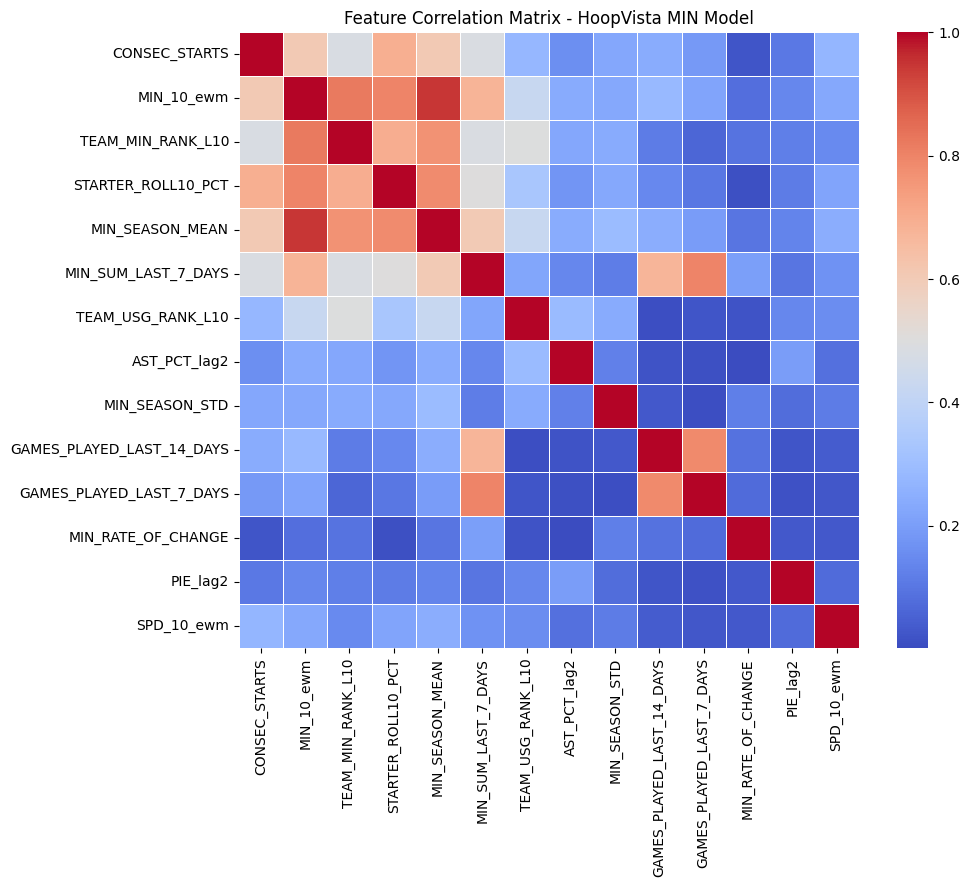

--- High Correlation Report (Threshold > 0.95) ---
No features exceed the correlation threshold.


[]

In [17]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, MIN_FEATURES)
correlated_features

In [18]:
# ════════════════════════════════════════════════════════════════════════════
# BLIND HOLDOUT TEST — S26
#
# NEW: evaluate on the season the model never saw during development.
# Run this cell once. If you iterate after seeing these numbers,
# S26 is no longer a clean holdout.
# ════════════════════════════════════════════════════════════════════════════

print("── S26 Blind Holdout Evaluation ─────────────────────────────────────")
print("  S22–S25: 90% rows for fit, last 10% for early-stopping only; predict S26 (never in eval_set).")

X_train_full = ppm_df[MIN_FEATURES]
y_train_full = ppm_df["MIN"]
X_ho         = ppm_holdout[MIN_FEATURES]
y_ho         = ppm_holdout["MIN"]
starting_ho  = ppm_holdout["STARTING"].values

# Early stopping on last 10% of training only — S26 must not be eval_set
# or best_iteration is tuned to the holdout.
es_cutoff  = int(len(X_train_full) * 0.90)
X_es_train = X_train_full.iloc[:es_cutoff]
y_es_train = y_train_full.iloc[:es_cutoff]
X_es_val   = X_train_full.iloc[es_cutoff:]
y_es_val   = y_train_full.iloc[es_cutoff:]

models_ho, _ = fit_quantile_models(X_es_train, y_es_train, X_es_val, y_es_val)
preds_ho = {k: models_ho[k].predict(X_ho) for k in models_ho}

ho_metrics = score_fold(
    y_ho.values, preds_ho, models_ho,
    "S26 Blind Holdout",
    starting=starting_ho
)

# Compare walk-forward MAE vs holdout MAE — gap indicates how optimistic
# the WF estimate was
wf_mae_mean = np.mean([r["mae"] for r in wf_results])
ho_mae      = ho_metrics["mae"]
gap         = ho_mae - wf_mae_mean

print(f"\n{'─'*55}")
print(f"  Walk-forward MAE (mean, S22–S25)  : {wf_mae_mean:.3f} min")
print(f"  Holdout MAE      (S26)            : {ho_mae:.3f} min")
print(f"  Gap                               : {gap:+.3f} min  {'⚠ investigate' if abs(gap) > 0.5 else '✓ acceptable'}")

# Per-quantile calibration on holdout
print(f"\nHoldout quantile calibration (should match target):")
for q_key, target in [("q_0.10", 0.10), ("q_0.50", 0.50), ("q_0.90", 0.90)]:
    pred    = preds_ho[q_key]
    actual  = y_ho.values
    actual_coverage = (actual <= pred).mean()
    delta   = actual_coverage - target
    flag    = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {q_key} | actual coverage: {actual_coverage:.1%}  target: {target:.0%}  delta: {delta:+.1%}  {flag}")

# Interval width on holdout
interval_width = preds_ho["q_0.90"] - preds_ho["q_0.10"]
print(f"\nHoldout 80% interval width (Q10→Q90):")
print(f"  mean: {interval_width.mean():.2f} min  |  median: {np.median(interval_width):.2f} min  |  std: {interval_width.std():.2f} min")

── S26 Blind Holdout Evaluation ─────────────────────────────────────
  S22–S25: 90% rows for fit, last 10% for early-stopping only; predict S26 (never in eval_set).

S26 Blind Holdout
  Overall  | n=25693 | MAE: 4.320 | R²: 0.610 | 80% Coverage: 79.9%
  Starters   | n=12928 | MAE: 4.186 | Coverage: 80.5%
  Bench      | n=12765 | MAE: 4.456 | Coverage: 79.3%
  <10 min    | n= 1997 | MAE: 6.399 | Coverage: 52.9%
  10-20 min  | n= 6604 | MAE: 4.149 | Coverage: 84.4%
  20-30 min  | n= 9673 | MAE: 4.374 | Coverage: 83.2%
  30+ min    | n= 7419 | MAE: 3.843 | Coverage: 78.9%

───────────────────────────────────────────────────────
  Walk-forward MAE (mean, S22–S25)  : 4.276 min
  Holdout MAE      (S26)            : 4.320 min
  Gap                               : +0.045 min  ✓ acceptable

Holdout quantile calibration (should match target):
  q_0.10 | actual coverage: 10.3%  target: 10%  delta: +0.3%  ✓
  q_0.50 | actual coverage: 51.9%  target: 50%  delta: +1.9%  ✓
  q_0.90 | actual coverage

In [19]:
import joblib
from pathlib import Path

# ── resolve save directory relative to this notebook ─────────────────────────
# Works on any machine regardless of OS or username.
# Structure: <repo_root>/src/models/saved_models/
# Assumes notebook lives somewhere inside the repo (e.g. notebooks/ or root).

REPO_ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path.cwd()
save_dir  = REPO_ROOT / "src" / "models" / "saved_models"
save_dir.mkdir(parents=True, exist_ok=True)

# ── save ──────────────────────────────────────────────────────────────────────
bundle = {
    "quantile_models": models_ho,
    "feature_names":   MIN_FEATURES,
    "fold_metrics":    wf_results,
    "holdout_metrics": ho_metrics,
    "train_end":       ppm_df["GAME_DATE"].max(),
    "val_end":         ppm_holdout["GAME_DATE"].max(),
}

save_path = save_dir / f"min_quantile_xgb_v2_{ppm_holdout['GAME_DATE'].max().date()}.joblib"
joblib.dump(bundle, save_path)
print(f"Saved to {save_path}")

# ── load ──────────────────────────────────────────────────────────────────────
bundle        = joblib.load(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

test_preds = models_loaded["q_0.50"].predict(X_ho)
print(f"Loaded model MAE (S26 holdout): {mean_absolute_error(y_ho, test_preds):.3f}")
print(f"Trained on data up to        : {bundle['train_end'].date()}")
print(f"Holdout through              : {bundle['val_end'].date()}")

# ── inference ─────────────────────────────────────────────────────────────────
def predict_minutes(player_features: pd.DataFrame) -> pd.DataFrame:
    """
    Pass in a DataFrame with the same columns as MIN_FEATURES.
    Returns Q10 / Q50 / Q90 predictions per row.
    """
    assert list(player_features.columns) == feature_names, \
        f"Feature mismatch — expected {feature_names}"

    return pd.DataFrame({
        "q10": models_loaded["q_0.10"].predict(player_features),
        "q50": models_loaded["q_0.50"].predict(player_features),
        "q90": models_loaded["q_0.90"].predict(player_features),
    })

Saved to c:\Users\alexg\OneDrive\Documents\NBA-Prop-Predictor\src\models\saved_models\min_quantile_xgb_v2_2026-05-11.joblib
Loaded model MAE (S26 holdout): 4.320
Trained on data up to        : 2025-06-22
Holdout through              : 2026-05-11
